# Semana 2 Clase 3

En las clases anteriores trabajamos modelos deterministas con una sola variable principal, como población, temperatura o número total de individuos. Hoy estudiaremos un modelo con varias variables que evolucionan simultáneamente.

## Modelo epidemiológico SIR básico

$$
\frac{dS}{dt} = -\beta \frac{S I}{N}
$$

$$
\frac{dI}{dt} = \beta \frac{S I}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

Supongamos que en una población de tamaño fijo aparece una enfermedad infecciosa.

Al inicio, la mayoría de las personas son susceptibles, unas pocas están infectadas y ninguna se ha recuperado.

Queremos responder:

$$
\text{¿Cómo evoluciona el número de susceptibles, infectados y recuperados con el tiempo?}
$$

Este tipo de modelo permite explorar preguntas como:

*   ¿Cuándo ocurre el pico de infectados?
*   ¿Qué pasa si la tasa de contagio aumenta?
*   ¿Qué pasa si la recuperación es más rápida?
*   ¿Cómo cambian los escenarios si modificamos los parámetros?

## 1. Variables del modelo

Dividimos la población en tres grupos:

$$
S_t = \text{número de personas susceptibles en el tiempo } t,
$$

$$
I_t = \text{número de personas infectadas en el tiempo } t,
$$

$$
R_t = \text{número de personas recuperadas en el tiempo } t.
$$

La población total es:

$$
N = S_t + I_t + R_t.
$$

En el modelo básico se supone que $N$ permanece constante.



## 2. Parámetros del modelo

El modelo tiene dos parámetros principales:

$$
\beta = \text{tasa de contagio},
$$

$$
\gamma = \text{tasa de recuperación}.
$$

Interpretación:

*   Si $\beta$ aumenta, los contagios ocurren más rápido.
*   Si $\gamma$ aumenta, los infectados se recuperan más rápido.
*   La relación entre ambos parámetros ayuda a determinar si la infección crece o desaparece.

## 3. Supuestos del modelo

Puedes pedir primero que los alumnos propongan supuestos. Después puedes formalizar:

1.  La población total permanece constante.
2.  No se consideran nacimientos ni muertes.
3.  Todas las personas tienen la misma probabilidad de entrar en contacto.
4.  Una persona susceptible puede infectarse al interactuar con personas infectadas.
5.  Una persona infectada eventualmente pasa al grupo de recuperados.
6.  Las personas recuperadas no vuelven a infectarse durante el periodo estudiado.
7.  El modelo es determinista: con las mismas condiciones iniciales y parámetros, se obtiene siempre la misma trayectoria.


## 4. Modelo matemático discreto

Usaremos una versión en tiempo discreto del modelo SIR:

$$
S_{t+1} = S_t - \beta \frac{S_t I_t}{N},
$$

$$
I_{t+1} = I_t + \beta \frac{S_t I_t}{N} - \gamma I_t,
$$

$$
R_{t+1} = R_t + \gamma I_t.
$$

- La cantidad $\beta \frac{S_t I_t}{N}$ representa los nuevos contagios.

- La cantidad $\gamma I_t$ representa los nuevos recuperados.



## 5. Interpretación de las ecuaciones

**Susceptibles**

$$
S_{t+1} = S_t - \beta \frac{S_t I_t}{N}
$$

El número de susceptibles disminuye porque algunos se infectan.

**Infectados**

$$
I_{t+1} = I_t + \beta \frac{S_t I_t}{N} - \gamma I_t
$$

El número de infectados aumenta por nuevos contagios y disminuye por recuperaciones.

**Recuperados**

$$
R_{t+1} = R_t + \gamma I_t
$$

El número de recuperados aumenta conforme las personas infectadas se recuperan.


## 6. Condiciones iniciales

Supongamos una población de:

$$
N = 1000.
$$

Al inicio:

$$
S_0 = 990,
$$

$$
I_0 = 10,
$$

$$
R_0 = 0.
$$

Usaremos inicialmente:

$$
\beta = 0.30,
$$

$$
\gamma = 0.10.
$$



## 7. Primer cálculo manual

Antes de programar, hacemos un paso manual.

Con:

$$
S_0 = 990, \quad I_0 = 10, \quad R_0 = 0, \quad N = 1000,
$$

$$
\beta = 0.30, \quad \gamma = 0.10,
$$

los nuevos contagios son:

$$
\beta \frac{S_0 I_0}{N} = 0.30 \frac{(990)(10)}{1000}.
$$

$$
0.30 \frac{9900}{1000} = 0.30(9.9) = 2.97.
$$

Los nuevos recuperados son:

$$
\gamma I_0 = 0.10(10) = 1.
$$

Entonces:

$$
S_1 = 990 - 2.97 = 987.03,
$$

$$
I_1 = 10 + 2.97 - 1 = 11.97,
$$

$$
R_1 = 0 + 1 = 1.
$$

Interpretación: después de un periodo, el modelo estima aproximadamente 11.97 infectados y 1 recuperado.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Parámetros del modelo
N = 1000        
beta = 0.30     
gamma = 0.10    
n = 100         

# Condiciones iniciales
S0 = 990
I0 = 10
R0 = 0

# Listas para guardar resultados
tiempos = np.arange(0, n + 1)
S = []
I = []
R = []

# Valores iniciales
s = S0
i = I0
r = R0

# Simulación
for t in tiempos:
    S.append(s)
    I.append(i)
    R.append(r)

    nuevos_contagios = beta * s * i / N
    nuevos_recuperados = gamma * i

    s = s - nuevos_contagios
    i = i + nuevos_contagios - nuevos_recuperados
    r = r + nuevos_recuperados

# Crear DataFrame
df_sir = pd.DataFrame({
    "tiempo": tiempos,
    "susceptibles": S,
    "infectados": I,
    "recuperados": R
})

df_sir

,tiempo,susceptibles,infectados,recuperados
0,0,990.000000,10.000000,0.000000
1,1,987.030000,11.970000,1.000000
2,2,983.485575,14.317425,2.197000
3,3,979.261281,17.109976,3.628742
4,4,974.234740,20.425520,5.339740
...,...,...,...,...
96,96,52.919110,1.725433,945.355457
97,97,52.891717,1.580282,945.528000
98,98,52.866642,1.447329,945.686029
99,99,52.843687,1.325551,945.830762


Como el modelo supone población constante, debemos revisar que:

$$
S_t + I_t + R_t = N.
$$

In [4]:
df_sir["total"] = (
    df_sir["susceptibles"]
    + df_sir["infectados"]
    + df_sir["recuperados"]
)

df_sir[["tiempo", "total"]]

,tiempo,total
0,0,1000.0
1,1,1000.0
2,2,1000.0
3,3,1000.0
4,4,1000.0
...,...,...
96,96,1000.0
97,97,1000.0
98,98,1000.0
99,99,1000.0


In [5]:
print("Total mínimo:", df_sir["total"].min())
print("Total máximo:", df_sir["total"].max())

Total mínimo: 999.9999999999998
Total máximo: 1000.0000000000003


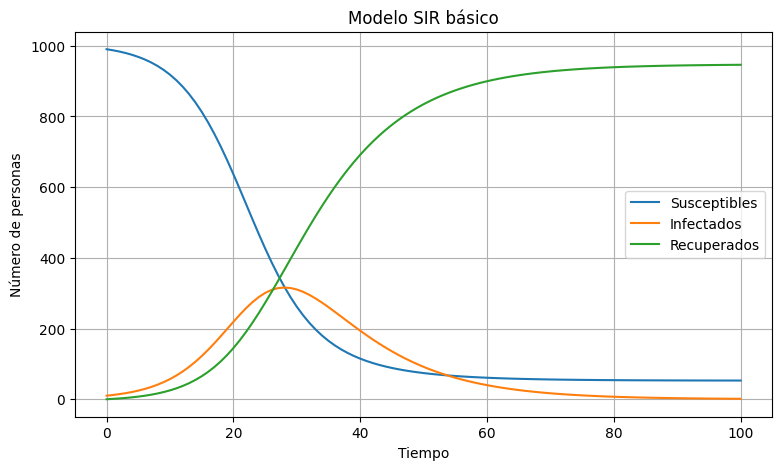

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(df_sir["tiempo"], df_sir["susceptibles"], label="Susceptibles")
plt.plot(df_sir["tiempo"], df_sir["infectados"], label="Infectados")
plt.plot(df_sir["tiempo"], df_sir["recuperados"], label="Recuperados")

plt.xlabel("Tiempo")
plt.ylabel("Número de personas")
plt.title("Modelo SIR básico")
plt.legend()
plt.grid()

plt.show()

- La curva de susceptibles disminuye porque cada vez hay menos personas que pueden infectarse.

- La curva de infectados primero aumenta, alcanza un máximo y luego disminuye.

- La curva de recuperados aumenta con el tiempo y eventualmente se estabiliza.

El pico de infectados representa el momento de mayor carga de la enfermedad en la población.

Encontrar el pico de infectados

In [7]:
idx_pico = df_sir["infectados"].idxmax()

tiempo_pico = df_sir.loc[idx_pico, "tiempo"]
infectados_pico = df_sir.loc[idx_pico, "infectados"]

print("Tiempo del pico:", tiempo_pico)
print("Número máximo de infectados:", infectados_pico)

Tiempo del pico: 28
Número máximo de infectados: 315.935724787338


El pico de infectados ocurre en el tiempo en que la cantidad $I_t$ alcanza su valor máximo. Este valor puede interpretarse como el momento de mayor intensidad del brote.

## Número reproductivo básico aproximado

En el modelo SIR básico, una cantidad importante es:

$$
R_0 = \frac{\beta}{\gamma}.
$$

**¿Qué significa esto?**
El número reproductivo básico ($R_0$) es el **número promedio de contagios directos que genera una sola persona infectada** durante todo su periodo de enfermedad, asumiendo que interactúa en una población donde todos son completamente susceptibles (nadie está vacunado ni ha tenido la enfermedad antes).

Nos sirve como un umbral para predecir qué pasará con la enfermedad:
*   **Si $R_0 > 1$:** La infección crecerá (brote epidémico), ya que cada infectado transmite la enfermedad a más de una persona.
*   **Si $R_0 < 1$:** La infección tenderá a desaparecer, ya que cada infectado no logra reemplazar su caso con un nuevo contagio.
*   **Si $R_0 = 1$:** La infección se mantendrá estable en la población (endemia).


In [8]:
# R_0 se usa comúnmente para el número reproductivo básico, 
# antes usamos R_0 para recuperados iniciales.
# Para evitar confusión, lo llamamos R_basico

R_basico = beta / gamma

print("Número reproductivo básico aproximado:", R_basico)

Número reproductivo básico aproximado: 2.9999999999999996


Esto sugiere que, al inicio, la infección puede crecer porque el número reproductivo básico es mayor que 1.

## Sensibilidad respecto a $\beta$

Ahora analizamos qué ocurre cuando cambia la tasa de contagio.

In [9]:
def simular_sir(N, S0, I0, R0, beta, gamma, n):
    tiempos = np.arange(0, n + 1)

    S = []
    I = []
    R = []

    s = S0
    i = I0
    r = R0

    for t in tiempos:
        S.append(s)
        I.append(i)
        R.append(r)

        nuevos_contagios = beta * s * i / N
        nuevos_recuperados = gamma * i

        s = s - nuevos_contagios
        i = i + nuevos_contagios - nuevos_recuperados
        r = r + nuevos_recuperados

    df = pd.DataFrame({
        "tiempo": tiempos,
        "susceptibles": S,
        "infectados": I,
        "recuperados": R
    })

    return df

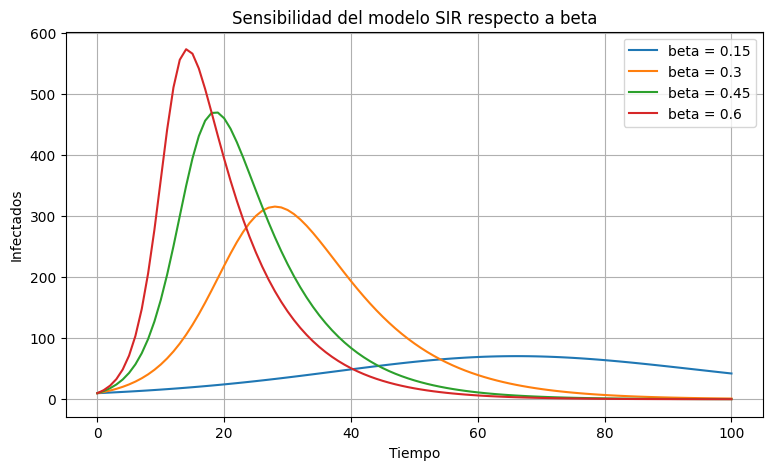

In [11]:
betas = [0.15, 0.30, 0.45, 0.6]
gamma = 0.10

plt.figure(figsize=(9, 5))

for beta in betas:
    df_temp = simular_sir(N, S0, I0, R0, beta, gamma, n)

    plt.plot(
        df_temp["tiempo"],
        df_temp["infectados"],
        label=f"beta = {beta}"
    )

plt.xlabel("Tiempo")
plt.ylabel("Infectados")
plt.title("Sensibilidad del modelo SIR respecto a beta")
plt.legend()
plt.grid()

plt.show()

#### Interpretación

Si $\beta$ aumenta, los contagios ocurren más rápido.

Esto suele producir:

*   un pico de infectados más alto;
*   un pico que ocurre más temprano;
*   una propagación más rápida de la enfermedad.

Si $\beta$ disminuye, el brote se vuelve más lento y puede tener menor intensidad.

## Sensibilidad respecto a $\gamma$

Ahora modificamos la tasa de recuperación.

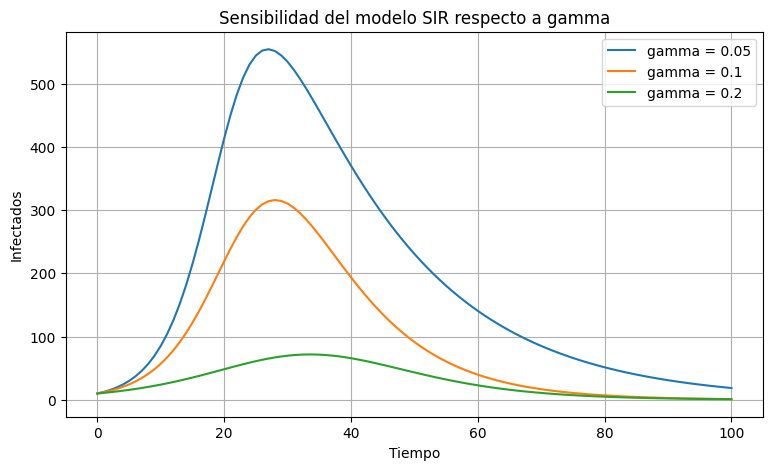

In [12]:
beta = 0.30
gammas = [0.05, 0.10, 0.20]

plt.figure(figsize=(9, 5))

for gamma in gammas:
    df_temp = simular_sir(N, S0, I0, R0, beta, gamma, n)

    plt.plot(
        df_temp["tiempo"],
        df_temp["infectados"],
        label=f"gamma = {gamma}"
    )

plt.xlabel("Tiempo")
plt.ylabel("Infectados")
plt.title("Sensibilidad del modelo SIR respecto a gamma")
plt.legend()
plt.grid()

plt.show()

#### Interpretación 

Si $\gamma$ aumenta, los infectados se recuperan más rápido.

Esto puede producir:

*   menor número máximo de infectados;
*   una duración menor del brote;
*   una reducción de la carga total de infección.

Si $\gamma$ disminuye, las personas permanecen infectadas por más tiempo y el brote puede ser más intenso.

### Tabla comparativa de escenarios

Construimos una tabla que resuma el pico de infectados para varios escenarios.

In [14]:
escenarios = [
    {"nombre": "Escenario A", "beta": 0.15, "gamma": 0.10},
    {"nombre": "Escenario B", "beta": 0.30, "gamma": 0.10},
    {"nombre": "Escenario C", "beta": 0.45, "gamma": 0.10},
    {"nombre": "Escenario D", "beta": 0.30, "gamma": 0.20},
]

resumen = []

for esc in escenarios:
    df_temp = simular_sir(
        N=N,
        S0=S0,
        I0=I0,
        R0=R0,
        beta=esc["beta"],
        gamma=esc["gamma"],
        n=n
    )

    idx_pico = df_temp["infectados"].idxmax()

    resumen.append({
        "escenario": esc["nombre"],
        "beta": esc["beta"],
        "gamma": esc["gamma"],
        "R_basico": esc["beta"] / esc["gamma"],
        "tiempo_pico": df_temp.loc[idx_pico, "tiempo"],
        "infectados_pico": df_temp.loc[idx_pico, "infectados"],
        "recuperados_finales": df_temp["recuperados"].iloc[-1]
    })

df_resumen = pd.DataFrame(resumen)

df_resumen

,escenario,beta,gamma,R_basico,tiempo_pico,infectados_pico,recuperados_finales
0,Escenario A,0.15,0.1,1.5,66,70.730731,469.942110
1,Escenario B,0.30,0.1,3.0,28,315.935725,945.963317
2,Escenario C,0.45,0.1,4.5,19,470.081495,991.666037
3,Escenario D,0.30,0.2,1.5,34,71.727716,598.100362


Gráfica comparativa de escenarios

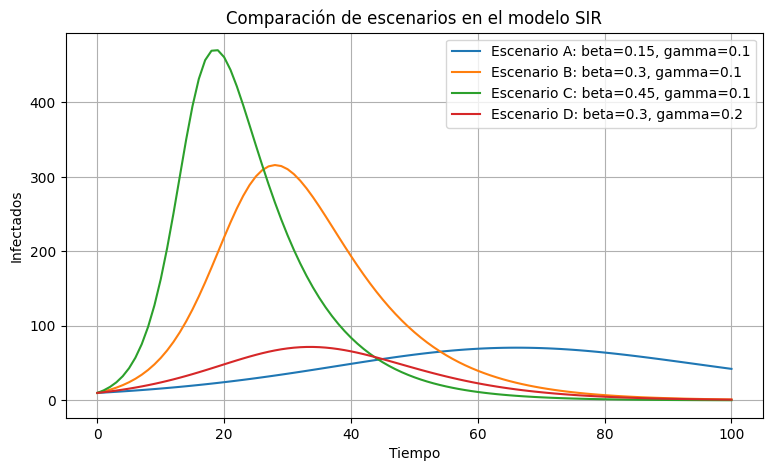

In [15]:
plt.figure(figsize=(9, 5))

for esc in escenarios:
    df_temp = simular_sir(
        N=N,
        S0=S0,
        I0=I0,
        R0=R0,
        beta=esc["beta"],
        gamma=esc["gamma"],
        n=n
    )

    plt.plot(
        df_temp["tiempo"],
        df_temp["infectados"],
        label=f"{esc['nombre']}: beta={esc['beta']}, gamma={esc['gamma']}"
    )

plt.xlabel("Tiempo")
plt.ylabel("Infectados")
plt.title("Comparación de escenarios en el modelo SIR")
plt.legend()
plt.grid()

plt.show()

### Limitaciones

El modelo SIR básico es útil para entender la dinámica general, pero tiene limitaciones importantes:

1.  Supone que toda la población se mezcla de manera homogénea.
2.  No considera edad, movilidad, contactos diferenciados ni redes sociales.
3.  No considera nacimientos ni muertes.
4.  No considera reinfecciones.
5.  No considera cambios en el comportamiento.
6.  No incorpora datos reales directamente.
7.  No incluye incertidumbre ni aleatoriedad.

**El valor de un modelo no está en que sea perfecto, sino en que permite entender una parte del fenómeno y explorar escenarios bajo supuestos explícitos.**

## Ajuste visual de un modelo SIR básico a casos semanales de sarampión en Chihuahua

In [3]:
ruta = 'https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/sarampion_chihuahua.csv'
df = pd.read_csv(ruta)
df.head()

,SEMANA_DIAG,AHUMADA,ALDAMA,ALLENDE,AQUILES SERDÁN,ASCENSIÓN,BACHÍNIVA,BALLEZA,BATOPILAS DE MANUEL GÓMEZ MORÍN,BOCOYNA,...,PRAXEDIS G. GUERRERO,RIVA PALACIO,ROSALES,SAN FRANCISCO DE BORJA,SAN FRANCISCO DE CONCHOS,SANTA ISABEL,SAUCILLO,TEMÓSACHIC,URIQUE,URUACHI
0,2025-02-24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-03-03,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
2,2025-03-10,0,0,0,0,0,0,0,0,0,...,0,10,0,0,0,0,0,0,0,0
3,2025-03-17,0,0,0,0,0,1,0,0,0,...,0,3,0,0,0,0,0,0,0,0
4,2025-03-24,8,0,0,0,0,2,0,0,0,...,0,8,0,0,0,0,0,0,0,0


In [12]:
df.columns

Index(['SEMANA_DIAG', 'AHUMADA', 'ALDAMA', 'ALLENDE', 'AQUILES SERDÁN',
       'ASCENSIÓN', 'BACHÍNIVA', 'BALLEZA', 'BATOPILAS DE MANUEL GÓMEZ MORÍN',
       'BOCOYNA', 'BUENAVENTURA', 'CAMARGO', 'CARICHÍ', 'CASAS GRANDES',
       'CHIHUAHUA', 'CORONADO', 'CUAUHTÉMOC', 'CUSIHUIRIACHI', 'DELICIAS',
       'GALEANA', 'GRAN MORELOS', 'GUACHOCHI', 'GUADALUPE Y CALVO',
       'GUAZAPARES', 'GUERRERO', 'GÓMEZ FARÍAS', 'HIDALGO DEL PARRAL', 'JANOS',
       'JIMÉNEZ', 'JULIMES', 'JUÁREZ', 'LA CRUZ', 'LÓPEZ', 'MADERA', 'MEOQUI',
       'MORELOS', 'NAMIQUIPA', 'NONOAVA', 'NUEVO CASAS GRANDES', 'OCAMPO',
       'OJINAGA', 'PRAXEDIS G. GUERRERO', 'RIVA PALACIO', 'ROSALES',
       'SAN FRANCISCO DE BORJA', 'SAN FRANCISCO DE CONCHOS', 'SANTA ISABEL',
       'SAUCILLO', 'TEMÓSACHIC', 'URIQUE', 'URUACHI', 'casos_semana'],
      dtype='str')

In [10]:
cols_municipios = [
 'AHUMADA',
 'ALDAMA',
 'ALLENDE',
 'AQUILES SERDÁN',
 'ASCENSIÓN',
 'BACHÍNIVA',
 'BALLEZA',
 'BATOPILAS DE MANUEL GÓMEZ MORÍN',
 'BOCOYNA',
 'BUENAVENTURA',
 'CAMARGO',
 'CARICHÍ',
 'CASAS GRANDES',
 'CHIHUAHUA',
 'CORONADO',
 'CUAUHTÉMOC',
 'CUSIHUIRIACHI',
 'DELICIAS',
 'GALEANA',
 'GRAN MORELOS',
 'GUACHOCHI',
 'GUADALUPE Y CALVO',
 'GUAZAPARES',
 'GUERRERO',
 'GÓMEZ FARÍAS',
 'HIDALGO DEL PARRAL',
 'JANOS',
 'JIMÉNEZ',
 'JULIMES',
 'JUÁREZ',
 'LA CRUZ',
 'LÓPEZ',
 'MADERA',
 'MEOQUI',
 'MORELOS',
 'NAMIQUIPA',
 'NONOAVA',
 'NUEVO CASAS GRANDES',
 'OCAMPO',
 'OJINAGA',
 'PRAXEDIS G. GUERRERO',
 'RIVA PALACIO',
 'ROSALES',
 'SAN FRANCISCO DE BORJA',
 'SAN FRANCISCO DE CONCHOS',
 'SANTA ISABEL',
 'SAUCILLO',
 'TEMÓSACHIC',
 'URIQUE',
 'URUACHI']

In [13]:
df["SEMANA_DIAG"] = pd.to_datetime(df["SEMANA_DIAG"])

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df[["SEMANA_DIAG", "casos_semana"]]

,SEMANA_DIAG,casos_semana
0,2025-02-24,3
1,2025-03-03,4
2,2025-03-10,31
3,2025-03-17,29
4,2025-03-24,89
5,2025-03-31,109
6,2025-04-07,207
7,2025-04-14,160
8,2025-04-21,226
9,2025-04-28,234


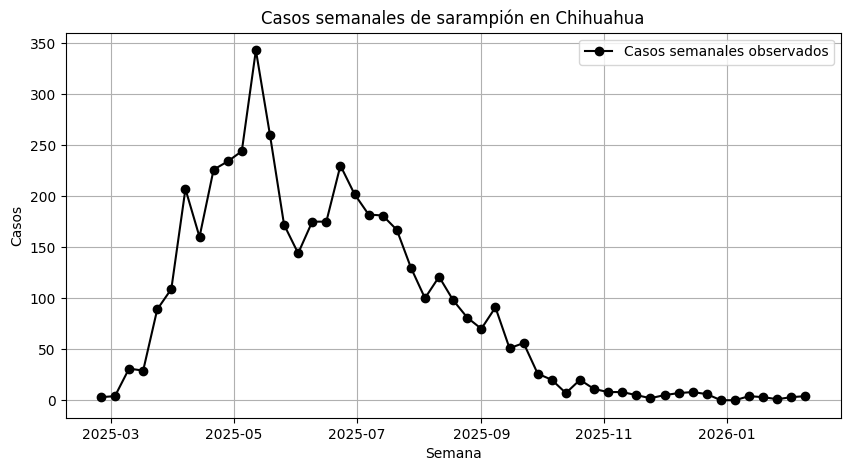

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["SEMANA_DIAG"],
    df["casos_semana"],
    marker="o",
    label="Casos semanales observados",
    color='black'
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos semanales de sarampión en Chihuahua")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

Modelo SIR básico con nuevos contagios

In [15]:
def simular_sir(N, I0, R0, beta, gamma, n):
    S0 = N - I0 - R0

    S = []
    I = []
    R = []
    nuevos = []

    s = S0
    i = I0
    r = R0

    for t in range(n):
        S.append(s)
        I.append(i)
        R.append(r)

        nuevos_contagios = beta * s * i / N
        nuevos_recuperados = gamma * i

        nuevos.append(nuevos_contagios)

        s = s - nuevos_contagios
        i = i + nuevos_contagios - nuevos_recuperados
        r = r + nuevos_recuperados

    return pd.DataFrame({
        "semana": range(n),
        "S": S,
        "I": I,
        "R": R,
        "nuevos_contagios": nuevos
    })

In [17]:
n

51

In [23]:
N = 3_700_000       # población aproximada de Chihuahua
I0 = df["casos_semana"].iloc[0]
R0 = 0

beta = 0.7
gamma = 0.1

n = len(df)

df_sir = simular_sir(N, I0, R0, beta, gamma, n)

df_sir.head()

,semana,S,I,R,nuevos_contagios
0,0,3.699997e+06,3.000000,0.000000,2.099998
1,1,3.699995e+06,4.799998,0.300000,3.359994
2,2,3.699992e+06,7.679993,0.780000,5.375983
3,3,3.699986e+06,12.287976,1.547999,8.601551
4,4,3.699978e+06,19.660729,2.776797,13.762427


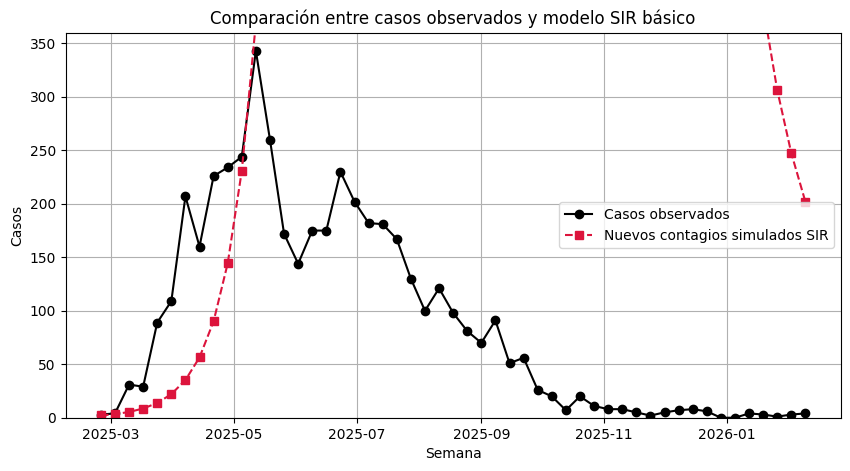

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["SEMANA_DIAG"],
    df["casos_semana"],
    marker="o",
    label="Casos observados", color='black'
)

plt.plot(
    df["SEMANA_DIAG"],
    df_sir["nuevos_contagios"],
    marker="s",
    linestyle="--",
    label="Nuevos contagios simulados SIR", color='crimson'
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Comparación entre casos observados y modelo SIR básico")
plt.xticks()
plt.legend()
plt.grid()
plt.ylim(0, 360)
plt.show()

Estos datos sí sirven para un ejercicio con SIR básico, pero no para afirmar que el modelo describe perfectamente el brote. Para un análisis más riguroso necesitaríamos población por municipio, periodo infeccioso, fecha de inicio de síntomas, información de vacunación, movilidad, subregistro y posiblemente un modelo más elaborado.